In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, maximum
from matplotlib.colors import LogNorm
import time

# Intro et initialisation des variables

In [2]:
carte = plt.imread("ori_carte_carres.png")


print("Les dimensions de notre carte sont :", carte.shape) # La valeur correspond aux différents canaux: RVBA
carte_grise = carte[:, :, 0] # n'importe qu'elle composante, car l'image est déjà en gris

Les dimensions de notre carte sont : (4800, 6400, 4)


In [3]:
colormapcustom = plt.get_cmap('hot_r').copy() # Pour des raisons esthetiques, on décide d'inverser la colormap.

Étant donné que le blanc correspond à la valeur numérique '1' et la couleur noir à la valeur '0', on décide d'inverser la carte. En effet, nous souhaitons le noir (ie la densité de population la plus haute) soit la valeur la plus elevée.

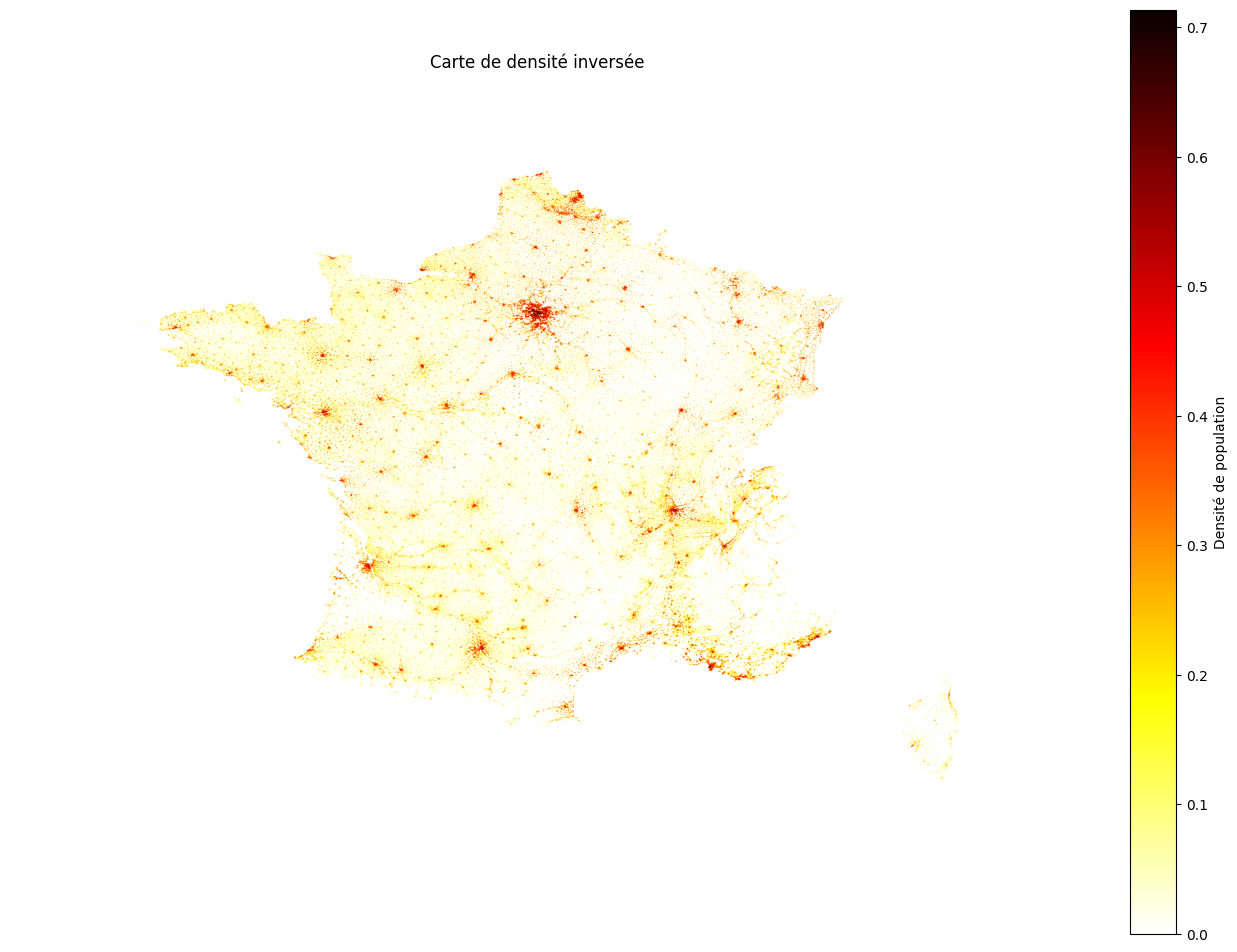

In [4]:
carte_inv = 1 - carte_grise

plt.figure(figsize=(17, 12)); plt.title("Carte de densité inversée")
plt.imshow(carte_inv, cmap=colormapcustom); plt.colorbar(cmap=colormapcustom, label="Densité de population")
plt.axis("off"); plt.show()

Nous découpons et catégorisons les densités de population. Les 3 niveaux utilisés par l'INSEE sont les suivants :
- Rural
- Urbain intermédiaire
- Urbain dense.



Notons $\rho$ la densité de couleur. Après un raisonnement étayé dans le rapport de stage (2.2 - Classification en trois niveaux de densité, page 3), nous obtenons les valeurs numériques suivantes :
- Rural $\iff \rho < 0.003 $ 
- Urbain intermédiaire $ \iff \rho \in [0.003, \,0.014 [ $  
- Urbain dense $\iff \rho \geq 0.014$

À chaque niveau, nous associons un chiffre. Le rural étant associé au chiffre 1, l'ubrain intermédiaire à 2 et l'urbain dense à 3.

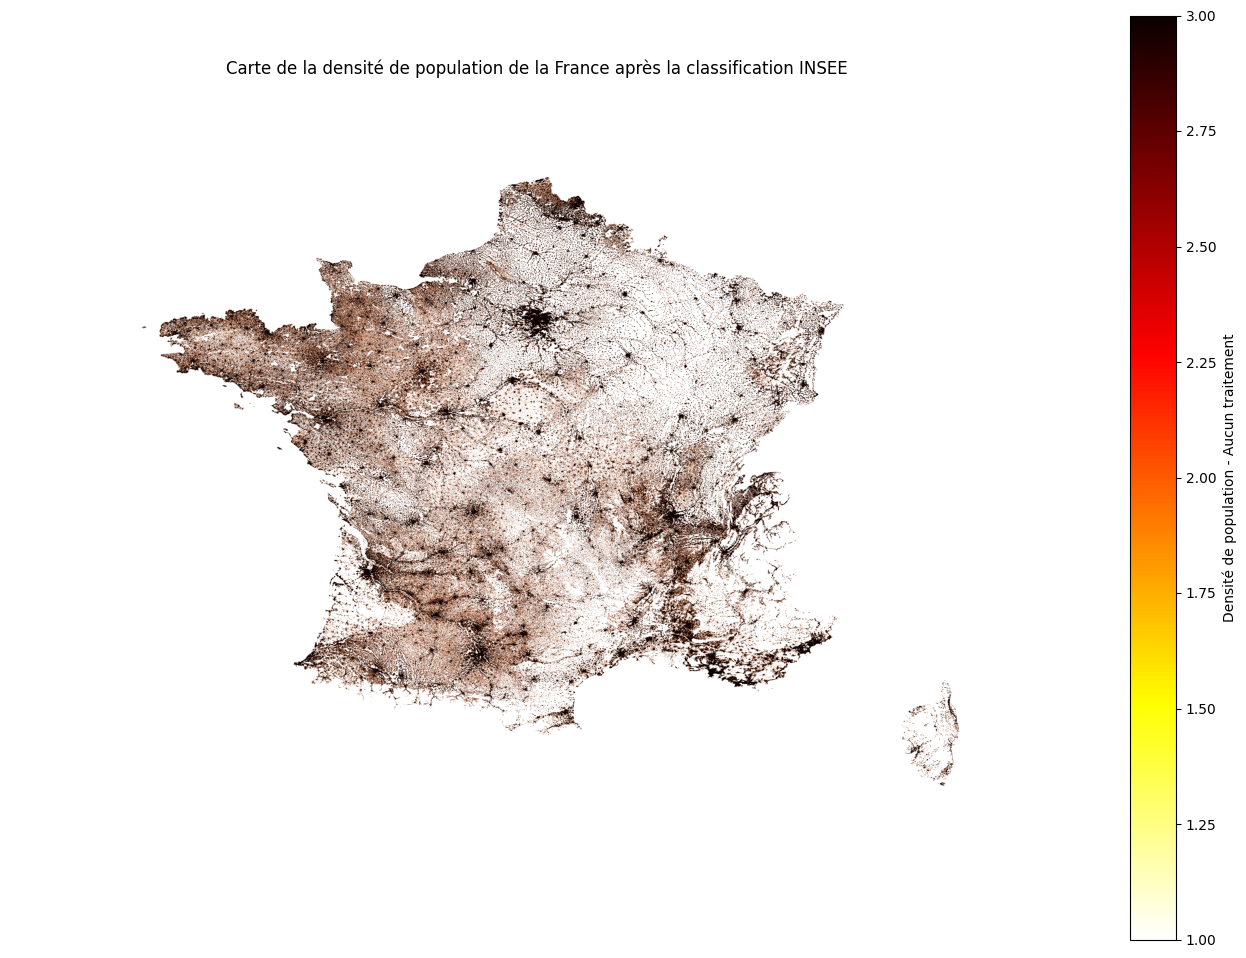

In [5]:
carte_densite = np.zeros(carte_inv.shape, dtype=int)


carte_densite[(carte_inv< 0.006)] = 1
carte_densite[(carte_inv< 0.03) & (carte_inv>=0.006)] = 2
carte_densite[carte_inv>=0.03] = 3


plt.figure(figsize=(17, 12))

plt.imshow(carte_densite, cmap=colormapcustom)
plt.colorbar(label='Densité de population - Aucun traitement')
plt.axis("off")
plt.title("Carte de la densité de population de la France après la classification INSEE")

# Attention, l'execution de la ligne ci-dessous prend du temps car vise à enregistrer la carte avec une très haute résolution 
#plt.savefig("output/carte_densite_pop_vanilla.png", format = 'png', dpi=1200)

plt.show()

# Stochastique

In [6]:
import scipy.sparse as sp
import gc #pr nettoyer ram
import cupy as cp # numpy pr CUDA
import cupyx.scipy.sparse as csp # scipy pr CUDA
from cupyx.scipy.sparse.linalg import cg  #pr gradient conjugué sur gpu
import matplotlib.patches as mpatches

C:\Users\33766\AppData\Roaming\Python\Python313\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## Intro et initialisation des variables

Modélisation Stochastique du problème



On note $u(x,y)$ l'espérance du nombre de pas nécessaires pour atteindre un pixel de l'ensemble des pixels de campagne depuis $(x, \,y)$.

- Si le marcheur démarre directement dans la campagne, le temps d'atteinte est nul : $u(x,y) = 0$

- Équation de propagation (Théorème de Feynman-Kac discret) : Si $(x,y)$ n'est pas dans la campagne, le marcheur fait un pas (coût de $1$ unité de temps) et se retrouve de façon équiprobable sur l'une des 4 cases adjacentes (Haut, Bas, Gauche, Droite). Par la loi de l'espérance totale (prop de Markov) : $$u(x,y) = 1 + \frac{1}{4} \Big( u(x+1,y) + u(x-1,y) + u(x,y+1) + u(x,y-1) \Big)$$
Donc, on a Laplacien :
$$4u(x,y) - u(x+1,y) - u(x-1,y) - u(x,y+1) - u(x,y-1) = 4$$

### Construction du système linéaire réduit et symétrique

On garde seulement les pixels qui sont dans une zone urbaine dense. Les pixels ruraux valent déjà 0, donc ils ne servent pas vraiment à résoudre le système. Ça revient à résoudre seulement :

$$A_{ville}u_{ville}=b_{ville}$$

Résumons :
- diagonale à 4 parce que c'est le laplacien discret,
- -1 quand le voisin est aussi une case urbaine,
- rien si le voisin est de la campagne vu que sa valeur est 0.

Nous créeons la matrice creuse sur le CPU, puis l'envoyons sur le GPU pour les calculs.

In [7]:
hauteur, largeur = carte_grise.shape
nb_pixels = hauteur * largeur


masque_ville = carte_densite == 3
nb_cases_ville = masque_ville.sum() #juste pr info, c'est le nbre d'inconnues

print("pixels en tout =", nb_pixels)
print("pixels gardés comme inconnues =", nb_cases_ville)

y_ville, x_ville = np.where(masque_ville) # on trouve indice x et y de ce qui est ville
numero_pixel_ville = y_ville * largeur + x_ville #pr transformer les deux id et les utiliser pr une liste imaginer carré  avec cases numérotées en commençant à 0 ça augmente de 1 en allant à la droite tjrs
# et un saut de ligne ça fait une augmentation de 1 par rapport à al dernièer ligne toute à droite


# table de traduction : numero dans l'image -> numero dans le petit système
pixel_vers_inconnue = np.full(nb_pixels, -1, dtype=np.int32) #On crée tableau taille image et rempli de blanc = -1//pas ville
pixel_vers_inconnue[numero_pixel_ville] = np.arange(nb_cases_ville) #On associe pixel/inconnue à une place dans le tab

print("déb mat. creuse")
debut = time.time()

lignes = []
colonnes = []
valeurs = []

num_inconnue = np.arange(nb_cases_ville)

#On crée la diagonale de la matrice :
lignes.append(num_inconnue) #va servir d'indices pr les lignes
colonnes.append(num_inconnue) #va servir d'indices pr les colonnes
valeurs.append(np.full(nb_cases_ville, 4.0, dtype=np.float32)) # On crée un vecteur rempli de 4



# voisin de droite
voisin_droite = x_ville < largeur - 1 #mask pr ne pas être dernières cases à droite
voisin_droite[voisin_droite] = masque_ville[y_ville[voisin_droite], x_ville[voisin_droite] + 1] #pr celles qui ont passé 1er filtre, on regarde case à droite pour voir si campagne ou pas, si c'est campagne on met pas ds matrice
#On a que pixels qui ont voisin à droite ET dont le voisin est urbain


lignes.append(num_inconnue[voisin_droite]) #ajoute à la liste lignes les identifiants des pixels qui ont un voisin valide à droite.
colonnes.append(pixel_vers_inconnue[numero_pixel_ville[voisin_droite] + 1]) #mask pr récup pos brute sur image de base des pixels validés puis on prend case immédiatement à droite; On applique ce mask sur tableau de l'image
valeurs.append(np.full(voisin_droite.sum(), -1.0, dtype=np.float32)) # donne nbre de True pr avoir nbre de villes qui ont voisin droite et on y associe -1 car on reste ds cas le cas où c'est ville car on part  du principe
#que ça sert à rien si pas ville au début



# voisin de gauche
voisin_gauche = x_ville > 0
voisin_gauche[voisin_gauche] = masque_ville[y_ville[voisin_gauche], x_ville[voisin_gauche] - 1]

lignes.append(num_inconnue[voisin_gauche])
colonnes.append(pixel_vers_inconnue[numero_pixel_ville[voisin_gauche] - 1])
valeurs.append(np.full(voisin_gauche.sum(), -1.0, dtype=np.float32))


# voisin en bas
voisin_bas = y_ville < hauteur - 1
voisin_bas[voisin_bas] = masque_ville[y_ville[voisin_bas] + 1, x_ville[voisin_bas]]

lignes.append(num_inconnue[voisin_bas])
colonnes.append(pixel_vers_inconnue[numero_pixel_ville[voisin_bas] + largeur])
valeurs.append(np.full(voisin_bas.sum(), -1.0, dtype=np.float32))


# voisin en haut
voisin_haut = y_ville > 0
voisin_haut[voisin_haut] = masque_ville[y_ville[voisin_haut] - 1, x_ville[voisin_haut]]

lignes.append(num_inconnue[voisin_haut])
colonnes.append(pixel_vers_inconnue[numero_pixel_ville[voisin_haut] - largeur])
valeurs.append(np.full(voisin_haut.sum(), -1.0, dtype=np.float32))




#fusion en tab 1D
lignes = np.concatenate(lignes)
colonnes = np.concatenate(colonnes)
valeurs = np.concatenate(valeurs)



matrice_ville_cpu = sp.coo_matrix(
    (valeurs, (lignes, colonnes)),
    shape=(nb_cases_ville, nb_cases_ville)
).tocsr()#construit matrice sparse pr convert en format csr car + opti pr inverser



del lignes, colonnes, valeurs, voisin_droite, voisin_gauche, voisin_bas, voisin_haut
gc.collect() #bruteforce pr vider ram occupée par var supp ligne juste avant

print("matrice ok en", round(time.time() - debut, 2), "secondes")

print("début sur gpu")
debut_gpu = time.time()

matrice_ville_gpu = csp.csr_matrix(matrice_ville_cpu) #transfert matrice sur vram
del matrice_ville_cpu #supp de la matrice sur ram
gc.collect() #bruteforce sys pr libérer la ram de l'élément suppligne précédente

second_membre_gpu = cp.full(nb_cases_ville, 4.0, dtype=cp.float32) # second membre  = matrice avec que des 4 dcc création directe sur VRAM


print("transfert vers gpu fin en", round(time.time() - debut_gpu, 2), "s")

print("résolution avec grad conjugué sur gpu")
debut_resolution = time.time()

campa_ville_gpu, info = cg(matrice_ville_gpu, second_membre_gpu, rtol=1e-3) #grad conj sur gpu, s'arrete qd err relat <=10^-3

if info == 0:
    print("ça a convergé en", round(time.time() - debut_resolution, 2), "s")
else:
    print("pas totalement convergé, code info =", info)

campagnitude = np.zeros((hauteur, largeur), dtype=np.float32)
campagnitude[masque_ville] = campa_ville_gpu.get() #transfert du résultat depuis VRAM vers RAM

print("calcul fini, on affiche la carte")


pixels en tout = 30720000
pixels gardés comme inconnues = 2048303
déb mat. creuse
matrice ok en 0.65 secondes
début sur gpu
transfert vers gpu fin en 0.92 s
résolution avec grad conjugué sur gpu
ça a convergé en 0.6 s
calcul fini, on affiche la carte


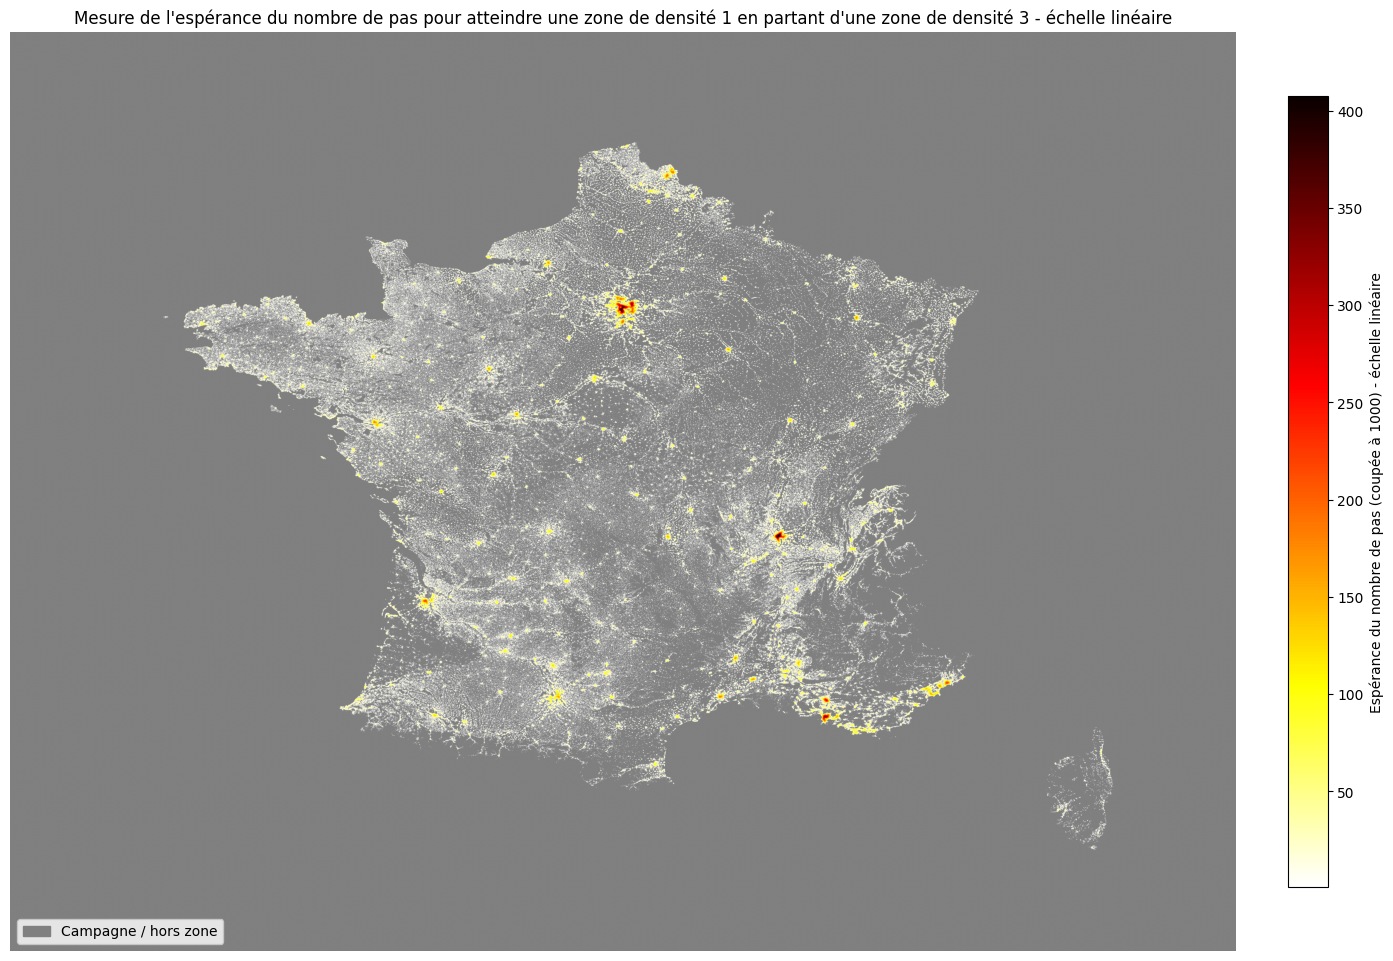

In [8]:
plt.figure(figsize=(17, 12))
plt.title("Mesure de l'espérance du nombre de pas pour atteindre une zone de densité 1 en partant d'une zone de densité 3 - échelle linéaire")
carte_campa = np.ma.masked_where(masque_ville == False, campagnitude)
image_campa = plt.imshow(carte_campa, cmap=colormapcustom, origin='upper')
barre = plt.colorbar(image_campa, fraction=0.03, pad=0.04)
barre.set_label("Espérance du nombre de pas (coupée à 1000) - échelle linéaire")


# gris et légende manuelle pour expliquer le gris
couleur_masque = "gray"
colormapcustom.set_bad(color=couleur_masque)

patch_campagne = mpatches.Patch(color=couleur_masque, label="Campagne / hors zone")
plt.legend(handles=[patch_campagne], loc='lower left', frameon=True)
plt.axis('off')



# Attention, l'execution de la ligne ci-dessous prend du temps car vise à enregistrer la carte avec une très haute résolution 
#plt.savefig("output/stocha/esperance_pas_RW_vers_zone_densite_1_no_log.png", format='png', dpi=1200)


plt.show()

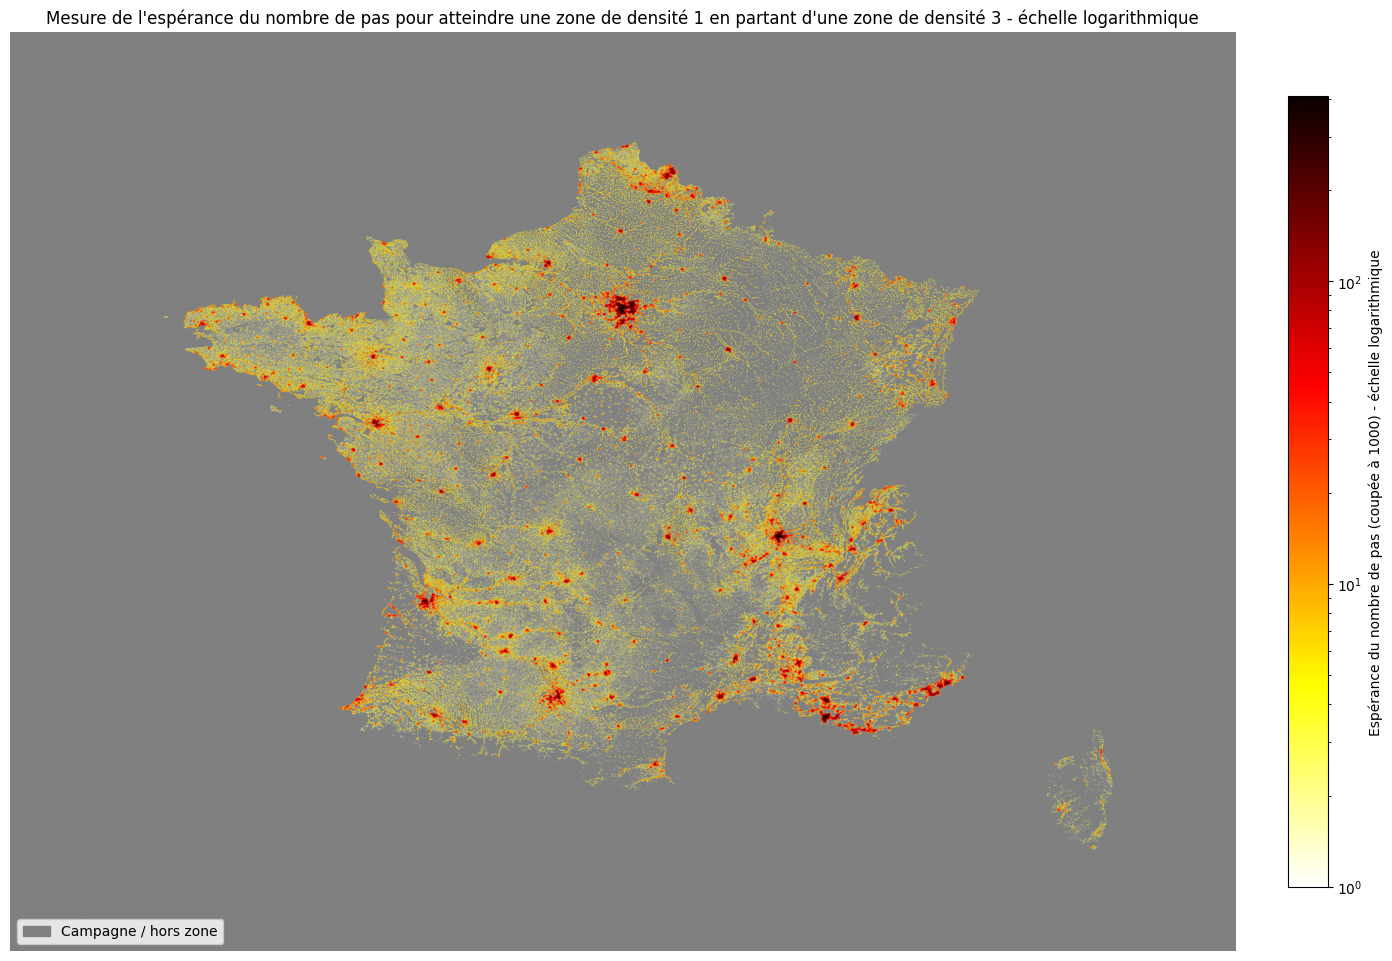

In [9]:
plt.figure(figsize=(17, 12))
plt.title("Mesure de l'espérance du nombre de pas pour atteindre une zone de densité 1 en partant d'une zone de densité 3 - échelle logarithmique")

carte_campa = np.ma.masked_where(masque_ville == False, campagnitude)

image_campa = plt.imshow(carte_campa, cmap=colormapcustom, origin='upper', norm=LogNorm(vmin=1, vmax=carte_campa.max()))

barre = plt.colorbar(image_campa, fraction=0.03, pad=0.04)
barre.set_label("Espérance du nombre de pas (coupée à 1000) - échelle logarithmique")

# gris & légende manuelle pour expliquer le gris
patch_campagne = mpatches.Patch(color=couleur_masque, label="Campagne / hors zone")
plt.legend(handles=[patch_campagne], loc='lower left', frameon=True)
plt.axis('off')


# Attention, l'execution de la ligne ci-dessous prend du temps car vise à enregistrer la carte avec une très haute résolution 
#plt.savefig("output/stocha/esperance_pas_RW_vers_zone_densite_1_log.png", format='png', dpi=1200)


plt.show()